# 阶段 A：数据选择（DeepMath-103K）

流水线阶段 A：在本地 DeepMath-103K Parquet 分片上应用**可解释的过滤规则**，产出便于 **SFT / RL（如基于验证器的 EM 奖励）** 使用的子集。

**数据来源**：`datasets/DeepMath-103K/data/train-*.parquet`  
**字段**（参见仓库 `dataset_infos.json`）：`question`, `final_answer`, `difficulty`, `topic`, `r1_solution_1..3`。

## 过滤目标

1. **降低模糊性**：剔除题干含糊、开放性过强或易与“证明/反证”类双分支任务混淆的样本。
2. **答案可验证 / 格式清晰**：`final_answer` 非空、长度在合理范围内，并可做规范化以适配 **Exact Match**。
3. **控制长度与难度**：题干长度上下界、`difficulty` 区间（DeepMath 中难度约为 **1–10**，亦可能出现 **-1** 占位，默认剔除）。


In [1]:
from __future__ import annotations

import json
import re
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "datasets" / "DeepMath-103K" / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "phase_a_deepmath"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.is_dir(), f"缺少数据目录：{DATA_DIR}"
sorted(DATA_DIR.glob("train-*.parquet"))[:3]

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[PosixPath('/Users/wayne/term2/5740/final project/datasets/DeepMath-103K/data/train-00000-of-00010.parquet'),
 PosixPath('/Users/wayne/term2/5740/final project/datasets/DeepMath-103K/data/train-00001-of-00010.parquet'),
 PosixPath('/Users/wayne/term2/5740/final project/datasets/DeepMath-103K/data/train-00002-of-00010.parquet')]

In [2]:
from __future__ import annotations

@dataclass
class FilterConfig:
    # 阶段 A 过滤超参：请根据团队在报告中的消融实验调整。
    min_question_chars: int = 30
    max_question_chars: int = 4000
    min_final_answer_chars: int = 1
    max_final_answer_chars: int = 512
    min_difficulty: float = 1.0
    max_difficulty: float = 10.0
    require_any_r1_solution: bool = True
    min_r1_solution_chars: int = 200
    topic_prefix_allowlist: tuple[str, ...] | None = None
    ambiguity_regexes: tuple[str, ...] = (
        r"\bprove\s+or\s+disprove\b",
        r"\btrue\s+or\s+false\b",
        r"\b(dis)?prove\s+that\b.*\bor\s+disprove\b",
        r"\bdoes\s+there\s+exist\b.*\b(if\s+so\b|otherwise)\b",
        r"\b(open\s+problem|unsolved|conjecture)\b",
        r"\b(value can be any|answers may vary|multiple answers)\b",
    )


CFG = FilterConfig()

In [3]:
def load_deepmath_frames(data_dir: Path) -> pd.DataFrame:
    paths = sorted(data_dir.glob("train-*.parquet"))
    if not paths:
        raise FileNotFoundError(f"未找到 Parquet：{data_dir}")
    tables = [pq.read_table(p) for p in tqdm(paths, desc="读取 Parquet")]
    return pa.concat_tables(tables).to_pandas()


df_raw = load_deepmath_frames(DATA_DIR)
print("总行数:", len(df_raw))
df_raw.head(2)

读取 Parquet:   0%|          | 0/10 [00:00<?, ?it/s]

读取 Parquet: 100%|██████████| 10/10 [00:01<00:00,  5.53it/s]

总行数: 103022


,question,final_answer,difficulty,topic,r1_solution_1,r1_solution_2,r1_solution_3
0,Evaluate the limit: \[ \lim_{x \to \infty} \sq...,0,4.5,Mathematics -> Precalculus -> Limits,"Okay, so I have this limit to evaluate: the li...","Okay, so I need to evaluate the limit as x app...","Okay, so I need to evaluate the limit as x app..."
1,Find the auxiliary equation for the ordinary d...,m^2 + 1 = 0,5.0,Mathematics -> Differential Equations -> Ordin...,"Okay, so I need to find the auxiliary equation...","Okay, so I need to find the auxiliary equation...","Okay, so I need to find the auxiliary equation..."


字段: ['question', 'final_answer', 'difficulty', 'topic', 'r1_solution_1', 'r1_solution_2', 'r1_solution_3']
缺失值:
question         0
final_answer     0
difficulty       0
topic            0
r1_solution_1    0
r1_solution_2    0
r1_solution_3    0
dtype: int64
题干长度 分位数: {0.01: 57.0, 0.5: 174.0, 0.9: 348.0, 0.99: 631.0}
答案长度 分位数: {0.01: 1.0, 0.5: 3.0, 0.9: 13.0, 0.99: 20.0}


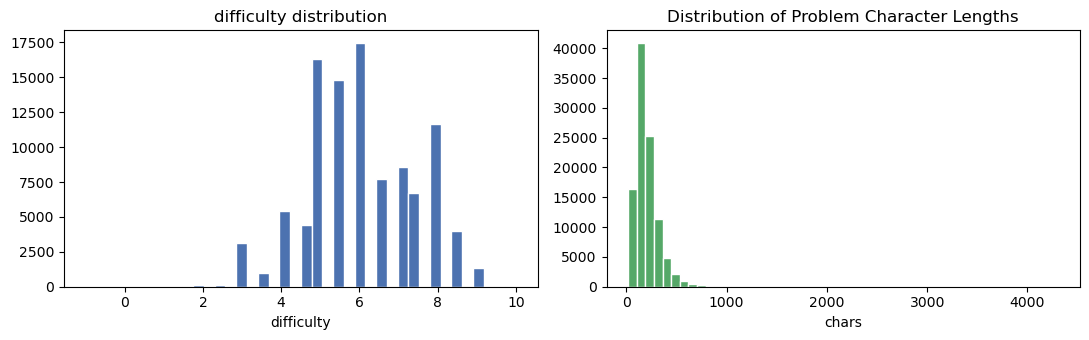

In [4]:
def summarize_base(table: pd.DataFrame) -> None:
    print("字段:", list(table.columns))
    print("缺失值:")
    print(table.isna().sum())
    q_lens = table["question"].astype(str).str.len()
    a_lens = table["final_answer"].astype(str).str.len()
    print("题干长度 分位数:", q_lens.quantile([0.01, 0.5, 0.9, 0.99]).to_dict())
    print("答案长度 分位数:", a_lens.quantile([0.01, 0.5, 0.9, 0.99]).to_dict())
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].hist(table["difficulty"], bins=40, color="#4C72B0", edgecolor="white")
    ax[0].set_title("difficulty distribution") # 难度分布
    ax[0].set_xlabel("difficulty")
    ax[1].hist(q_lens, bins=50, color="#55A868", edgecolor="white")
    ax[1].set_title("Distribution of Problem Character Lengths") # 题干字符长度分布
    ax[1].set_xlabel("chars")
    plt.tight_layout()
    plt.show()


summarize_base(df_raw)

In [5]:
def normalize_final_answer(text: str) -> str:
    # 规范化最终答案：合并空白、剥掉单层外围 $...$（若成对出现）以便 EM。
    s = text.strip()
    s = re.sub(r"\s+", " ", s)
    if len(s) >= 2 and s.startswith("$") and s.endswith("$") and s.count("$") == 2:
        s = s[1:-1].strip()
    return s


def longest_r1_solution(row: pd.Series) -> str:
    parts: list[str] = []
    for k in ("r1_solution_1", "r1_solution_2", "r1_solution_3"):
        v = row.get(k)
        if isinstance(v, str) and v.strip():
            parts.append(v.strip())
    return max(parts, key=len) if parts else ""


_BOXED_RE = re.compile(r"\\boxed\s*\{", re.IGNORECASE)


def solution_has_boxed(text: str) -> bool:
    return bool(_BOXED_RE.search(text or ""))


def ensure_boxed_suffix(solution: str, norm_answer: str) -> str:
    """若文本中尚无 \\boxed{...}，则在末尾用 final_answer_norm 补上标准 \\boxed{answer}，供 RL 格式奖励 / 解析使用。"""
    s = (solution or "").rstrip()
    if solution_has_boxed(s):
        return s
    ans = (norm_answer or "").strip()
    if not ans:
        return s
    sep = "\n\n" if s else ""
    return f"{s}{sep}\\boxed{{{ans}}}"


def matches_ambiguity(text: str, patterns: tuple[str, ...]) -> bool:
    low = text.lower()
    return any(re.search(p, low) for p in patterns)


def apply_filters(table: pd.DataFrame, cfg: FilterConfig) -> tuple[pd.DataFrame, dict[str, int], pd.Series]:
    # 每条样本只记录最先触发的剔除原因。
    t = table.copy()
    idx = t.index
    reason = pd.Series([""] * len(t), index=idx, dtype=object)
    q = t["question"].astype(str)
    fa_raw = t["final_answer"].astype(str)
    fa_norm = fa_raw.map(normalize_final_answer)
    diff = t["difficulty"]

    def mark(mask: pd.Series, name: str) -> None:
        m = mask & (reason == "")
        reason.loc[m] = name

    mark(~diff.between(cfg.min_difficulty, cfg.max_difficulty), "difficulty_out_of_range")
    mark(q.str.len() < cfg.min_question_chars, "question_too_short")
    mark(q.str.len() > cfg.max_question_chars, "question_too_long")
    mark(fa_norm.str.len() < cfg.min_final_answer_chars, "answer_empty")
    mark(fa_norm.str.len() > cfg.max_final_answer_chars, "answer_too_long")
    mark(q.map(lambda s: matches_ambiguity(s, cfg.ambiguity_regexes)), "ambiguous_question_pattern")
    if cfg.topic_prefix_allowlist is not None:
        allow = cfg.topic_prefix_allowlist
        tp = t["topic"].astype(str)
        mask_topic = tp.map(lambda s: any(s.startswith(pref) for pref in allow))
        mark(~mask_topic, "topic_not_in_allowlist")
    if cfg.require_any_r1_solution:
        r1_lens = t.apply(longest_r1_solution, axis=1).str.len()
        mark(r1_lens < cfg.min_r1_solution_chars, "no_usable_r1_solution")
    kept = reason == ""
    out = t.loc[kept].copy()
    out["final_answer_norm"] = fa_norm.loc[kept]
    dropped_counts = reason[reason != ""].value_counts().to_dict()
    return out, dropped_counts, reason


df_filt, dropped, reason_all = apply_filters(df_raw, CFG)
print("保留:", len(df_filt), "/", len(df_raw))
print("剔除（每条样本仅计首次命中原因）:")
print(json.dumps(dropped, indent=2, ensure_ascii=False))

保留: 100891 / 103022
剔除（每条样本仅计首次命中原因）:
{
  "ambiguous_question_pattern": 2050,
  "question_too_short": 73,
  "difficulty_out_of_range": 4,
  "answer_empty": 2,
  "question_too_long": 2
}


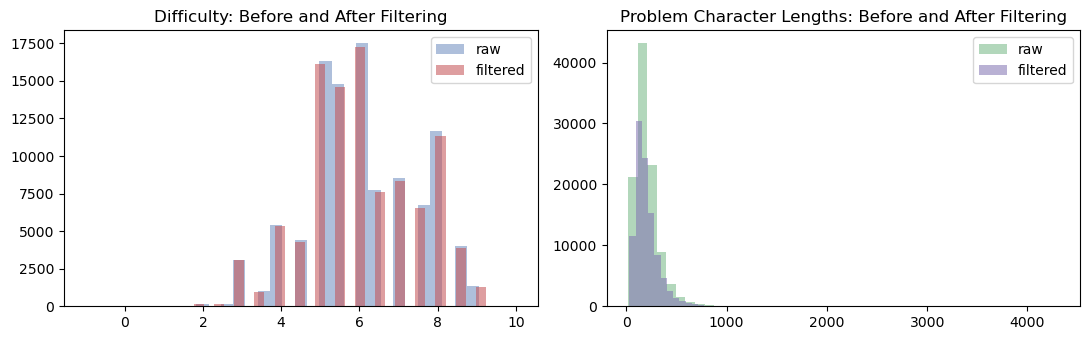

In [6]:
def plot_after_filter(raw: pd.DataFrame, filt: pd.DataFrame) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].hist(raw["difficulty"], bins=35, alpha=0.45, label="raw", color="#4C72B0")
    ax[0].hist(filt["difficulty"], bins=35, alpha=0.55, label="filtered", color="#C44E52")
    ax[0].legend()
    ax[0].set_title("Difficulty: Before and After Filtering")
    q_raw = raw["question"].astype(str).str.len()
    q_f = filt["question"].astype(str).str.len()
    ax[1].hist(q_raw, bins=45, alpha=0.45, label="raw", color="#55A868")
    ax[1].hist(q_f, bins=45, alpha=0.55, label="filtered", color="#8172B2")
    ax[1].legend()
    ax[1].set_title("Problem Character Lengths: Before and After Filtering")
    plt.tight_layout()
    plt.show()


plot_after_filter(df_raw, df_filt)

## 导出给下游（Parquet / JSONL）

- `deepmath_phase_a.parquet`：完整列 + `final_answer_norm`；三条 `r1_solution_*` 已按需**补全**标准 `\boxed{answer}`（与 `final_answer_norm` 一致），便于 RL 阶段做「含 boxed」的格式奖励。
- `deepmath_phase_a_alpaca.jsonl`：**Alpaca** 三列 `instruction` / `input` / `output`。`output` 基于最长 `r1_solution`，保证含 `\boxed{...}`，并保留 `Final answer: ...` 行便于对照。若答案字符串内含未转义的 `}`

In [7]:
def build_alpaca_records(df: pd.DataFrame) -> list[dict]:
    rows: list[dict] = []
    for _, row in df.iterrows():
        fa = str(row["final_answer_norm"])
        sol = ensure_boxed_suffix(longest_r1_solution(row), fa)
        output = sol.rstrip() + f"\n\nFinal answer: {fa}"
        rows.append(
            {
                "instruction": str(row["question"]),
                "input": "",
                "output": output,
                "difficulty": float(row["difficulty"]),
                "topic": str(row["topic"]),
                "final_answer_norm": fa,
            }
        )
    return rows


parquet_path = OUTPUT_DIR / "deepmath_phase_a.parquet"
jsonl_path = OUTPUT_DIR / "deepmath_phase_a_alpaca.jsonl"
manifest_path = OUTPUT_DIR / "phase_a_manifest.json"

# Parquet：三条 R1 解答均保证含 \boxed{final_answer_norm}（供 RL / SFT 与原始对齐）
df_export = df_filt.copy()
_fa = df_export["final_answer_norm"].astype(str)
for _col in ("r1_solution_1", "r1_solution_2", "r1_solution_3"):
    df_export[_col] = [
        ensure_boxed_suffix("" if pd.isna(v) else str(v), f)
        for v, f in zip(df_export[_col], _fa)
    ]
df_export.to_parquet(parquet_path, index=False)
recs = build_alpaca_records(df_filt)
with jsonl_path.open("w", encoding="utf-8") as f:
    for r in recs:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

manifest = {
    "data_dir": str(DATA_DIR),
    "filter_config": asdict(CFG),
    "counts": {"raw": len(df_raw), "kept": len(df_filt), "dropped_first_reason": dropped},
    "outputs": {"parquet": str(parquet_path), "jsonl": str(jsonl_path)},
    "boxed_answer_policy": "每条 r1_solution_* 与 alpaca output 在无 \\boxed{ 时追加 \\boxed{final_answer_norm}",
}
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print("已写入:", parquet_path)
print("已写入:", jsonl_path)
print("已写入:", manifest_path)

已写入: /Users/wayne/term2/5740/final project/outputs/phase_a_deepmath/deepmath_phase_a.parquet
已写入: /Users/wayne/term2/5740/final project/outputs/phase_a_deepmath/deepmath_phase_a_alpaca.jsonl
已写入: /Users/wayne/term2/5740/final project/outputs/phase_a_deepmath/phase_a_manifest.json


## 消融 / 敏感性（难度阈值）

扫描若干 `min_difficulty`，观察保留率

In [8]:
sweep_mins = [1.0, 3.0, 5.0, 7.0]
rows = []
for m in sweep_mins:
    c = FilterConfig(**{**asdict(CFG), "min_difficulty": m})
    sub, dr, _ = apply_filters(df_raw, c)
    rows.append({"min_difficulty": m, "kept": len(sub), "rate": len(sub) / len(df_raw)})
pd.DataFrame(rows)

,min_difficulty,kept,rate
0,1.0,100891,0.979315
1,3.0,100576,0.976257
2,5.0,86894,0.843451
3,7.0,31413,0.304915
